# Pose Classification using MediaPipe Landmark Detection

In [22]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import json
import seaborn as sns
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report


Epoch 1
-------------------------------
Test Error:
 Accuracy: 71.0%, Avg loss: 1.317826

Train Accuracy: 52.6%
Epoch 2
-------------------------------
Test Error:
 Accuracy: 82.6%, Avg loss: 1.038918

Train Accuracy: 71.3%
Epoch 3
-------------------------------
Test Error:
 Accuracy: 90.3%, Avg loss: 0.803739

Train Accuracy: 80.3%
Epoch 4
-------------------------------
Test Error:
 Accuracy: 92.7%, Avg loss: 0.624373

Train Accuracy: 89.2%
Epoch 5
-------------------------------
Test Error:
 Accuracy: 93.8%, Avg loss: 0.490997

Train Accuracy: 93.0%
Epoch 6
-------------------------------
Test Error:
 Accuracy: 94.4%, Avg loss: 0.403658

Train Accuracy: 94.5%
Epoch 7
-------------------------------
Test Error:
 Accuracy: 95.2%, Avg loss: 0.352835

Train Accuracy: 95.2%
Epoch 8
-------------------------------
Test Error:
 Accuracy: 95.8%, Avg loss: 0.323355

Train Accuracy: 95.8%
Epoch 9
-------------------------------
Test Error:
 Accuracy: 96.1%, Avg loss: 0.308764

Train Accuracy

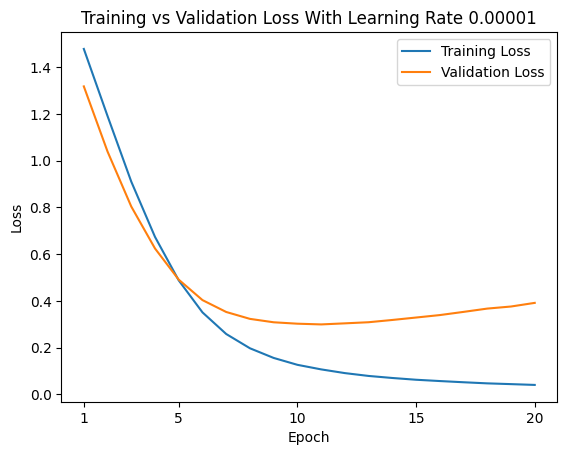

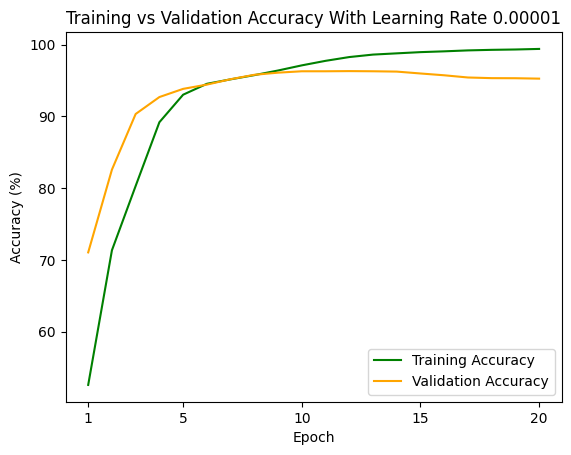

'test_df = pd.read_csv("poseData/dennis2.csv")\nX_test_processed = preprocess_pose_data(test_df.drop(\'label\', axis=1).values)\nX_test_scaled = scaler.transform(X_test_processed)\ny_test = encoder.transform(test_df[\'label\'].values)\n\nX_test_tensor = torch.tensor(X_test_scaled).float()\ny_test_tensor = torch.tensor(y_test).long()\n\ntest_dataset = TensorDataset(X_test_tensor, y_test_tensor)\ntest_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)    \n\ny_pred = []\ny_true = []\nmodel.eval()\nwith torch.no_grad():\n    for X_batch, y_batch in test_loader:\n        outputs = model(X_batch)\n        y_pred.extend(torch.argmax(outputs, dim=1).tolist())\n        y_true.extend(y_batch.tolist())\n\n\nclass_names = encoder.classes_\ncm = confusion_matrix(y_true, y_pred)\nplt.figure(figsize=(10, 8))\nsns.heatmap(cm, annot=True, fmt=\'d\', cmap=\'Blues\', \n            xticklabels=class_names, \n            yticklabels=class_names)\n\nplt.xlabel(\'Predicted Label\')\nplt.ylabel(

In [23]:
def calculate_angle(a, b, c):
    #Helper function to calculate angle between three points (in degrees)
    a, b, c = np.array(a), np.array(b), np.array(c)
    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = np.abs(radians * 180.0 / np.pi)
    return 360 - angle if angle > 180.0 else angle

def preprocess_pose_data(X_raw):
    # 1. Reshape and get N (fixing the shape tuple bug)
    X = X_raw.reshape(-1, 33, 2)
    N = X.shape[0]

    # 2. Hip Centering (Keep this for consistency)
    hip_center = (X[:, 24] + X[:, 23]) / 2
    X = X - hip_center[:, None, :]

    # 3. Torso Scaling
    shoulder_center = (X[:, 12] + X[:, 11]) / 2
    torso_length = np.linalg.norm(shoulder_center, axis=1)
    torso_length = np.maximum(torso_length, 1e-6)
    X_scaled = X / torso_length[:, None, None]

    # 4. Feature 1-4: The 4 existing angles
    angles = np.zeros((N, 4))
    for i in range(N):
        # Left/Right Elbow
        angles[i, 0] = calculate_angle(X_scaled[i,11], X_scaled[i,13], X_scaled[i,15])
        angles[i, 1] = calculate_angle(X_scaled[i,12], X_scaled[i,14], X_scaled[i,16])
        # Left/Right Shoulder
        angles[i, 2] = calculate_angle(X_scaled[i,23], X_scaled[i,11], X_scaled[i,13])
        angles[i, 3] = calculate_angle(X_scaled[i,24], X_scaled[i,12], X_scaled[i,14])

    # 5. Feature 5-6: Relative Wrist Heights (Crucial for up/down poses)
    # Distance from shoulder to wrist on Y axis
    l_wrist_y = (X_scaled[:, 11, 1] - X_scaled[:, 15, 1]).reshape(-1, 1)
    r_wrist_y = (X_scaled[:, 12, 1] - X_scaled[:, 16, 1]).reshape(-1, 1)

    # 6. Feature 7: Wrist-to-Wrist Distance (Crucial for crossed vs open arms)
    ww_dist = np.linalg.norm(X_scaled[:, 15] - X_scaled[:, 16], axis=1, keepdims=True)

    # 7. Feature 8: Average Hand-to-Hip Distance (Good for "Hands on Hips" detection)
    l_hand_hip = np.linalg.norm(X_scaled[:, 15] - X_scaled[:, 23], axis=1)
    r_hand_hip = np.linalg.norm(X_scaled[:, 16] - X_scaled[:, 24], axis=1)
    avg_hand_hip = ((l_hand_hip + r_hand_hip) / 2).reshape(-1, 1)

    # 8. Stack only these 8 features
    # Shape will be (N, 8)
    return np.hstack([angles, l_wrist_y, r_wrist_y, ww_dist, avg_hand_hip])

#Load the training and validation datasets
train_df1 = pd.read_csv('poseData/four-ppl-data.csv')
train_df2 = pd.read_csv('poseData/dennis-matt.csv')
train_df3 = pd.read_csv('poseData/matt-data.csv')
train_df4 = pd.read_csv('poseData/dennis-pose-data.csv') 
train_df = pd.concat([train_df1, train_df2, train_df3, train_df4], ignore_index=True)

val_df1 = pd.read_csv('poseData/marek-test.csv')
val_df2 = pd.read_csv('poseData/marek-anni-data.csv')
val_df = pd.concat([val_df1, val_df2], ignore_index=True)
    
#Data processing and feature engineering
X_train_processed = preprocess_pose_data(train_df.drop('label', axis=1).values)
X_val_processed = preprocess_pose_data(val_df.drop('label', axis=1).values)

#Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_val_scaled = scaler.transform(X_val_processed)

#Label encoding
encoder = LabelEncoder()
y_train = encoder.fit_transform(train_df['label'].values)
y_val = encoder.transform(val_df['label'].values) 

X_train_tensor = torch.tensor(X_train_scaled).float()
y_train_tensor = torch.tensor(y_train).long()

X_val_tensor = torch.tensor(X_val_scaled).float()
y_val_tensor = torch.tensor(y_val).long()

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset  = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader  = DataLoader(val_dataset, batch_size=32, shuffle=False)

# GROUP-BASED SPLIT

""" raw_labels = data['label'].values
segment_ids = np.zeros(len(raw_labels), dtype=int)
segment = 0
for i in range(1, len(raw_labels)):
    if raw_labels[i] != raw_labels[i - 1]:
        segment += 1
    segment_ids[i] = segment

# Each cycle has 4 classes
n_classes = len(np.unique(y))
cycle_ids = segment_ids // n_classes

print(f"Total segments: {segment + 1}")
print(f"Total cycles: {cycle_ids.max() + 1}")
print(f"Samples per cycle:")
for c in range(cycle_ids.max() + 1):
    mask = cycle_ids == c
    print(f"  Cycle {c}: {mask.sum()} samples, classes: {dict(zip(*np.unique(y[mask], return_counts=True)))}")

# Use last cycle as test, rest as train
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=cycle_ids))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]


# Verify no cycle overlap
train_cycles = set(cycle_ids[train_idx])
test_cycles = set(cycle_ids[test_idx])
print(f"\nTrain cycles: {sorted(train_cycles)}")
print(f"Test cycles:  {sorted(test_cycles)}")
print(f"Overlap: {len(train_cycles & test_cycles)} (should be 0)")


X_train_tensor = torch.tensor(X_train).float()
y_train_tensor = torch.tensor(y_train).long()

X_test_tensor = torch.tensor(X_test).float()
y_test_tensor = torch.tensor(y_test).long()

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32) """

# end of GROUP-BASED SPLIT 


######################################################################################################### 
### TRAIN VAL TEST SPLIT 
### 

# # 1. INITIAL SPLIT (Separate Test set entirely)
# X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# # 2. SECOND SPLIT (Split remaining into Train and Val)
# X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15, random_state=42)

# # 3. PREVENT LEAKAGE: Fit scaler ONLY on training data
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_val = scaler.transform(X_val)
# X_test = scaler.transform(X_test)

# # 4. CONVERT TO TENSORS
# X_train_tensor = torch.tensor(X_train).float()
# y_train_tensor = torch.tensor(y_train).long()
# X_val_tensor = torch.tensor(X_val).float()
# y_val_tensor = torch.tensor(y_val).long()
# X_test_tensor = torch.tensor(X_test).float()
# y_test_tensor = torch.tensor(y_test).long()

# # 5. DATALOADERS
# train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
# val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32)
# test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32)

### 
### END: TRAIN VAL TEST SPLIT 
################################################################################################

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# X_train_tensor = torch.tensor(X_train).float()
# y_train_tensor = torch.tensor(y_train).long()

# X_test_tensor = torch.tensor(X_test).float()
# y_test_tensor = torch.tensor(y_test).long()

# train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
# test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# test_loader  = DataLoader(test_dataset, batch_size=32)


class PoseClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(8, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 5)
        )

    def forward(self, x):
        return self.model(x)

model = PoseClassifier()
criterion = nn.CrossEntropyLoss()
learning_rate = lr = 1e-5
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
batch_size = 64
epochs = 20
def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    for batch, (X, y) in enumerate(dataloader):
        pred = model(X)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    avg_loss = total_loss / num_batches
    accuracy = correct / size
    return avg_loss, accuracy


def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            loss = loss_fn(pred, y)
            test_loss += loss.item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    accuracy = correct / size

    print(f"Test Error:\n Accuracy: {(100*accuracy):>0.1f}%, Avg loss: {test_loss:>8f}\n")
    return test_loss, accuracy

train_losses = []
test_losses = []
train_accuracies = []
val_accuracies = []

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")

    train_loss, train_acc = train_loop(train_loader, model, criterion, optimizer)
    test_loss, val_acc = test_loop(val_loader, model, criterion)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    print(f"Train Accuracy: {(100*train_acc):>0.1f}%")

print("Done!")


epoch_range = range(1, epochs + 1)
epoch_ticks = sorted(set(np.linspace(1, epochs, num=min(5, epochs), dtype=int).tolist()))

plt.plot(epoch_range, train_losses, label="Training Loss")
plt.plot(epoch_range, test_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss With Learning Rate 0.00001")
plt.xticks(epoch_ticks)
plt.legend()
plt.show()

plt.plot(epoch_range, [acc * 100 for acc in train_accuracies], label="Training Accuracy", color="green")
plt.plot(epoch_range, [acc * 100 for acc in val_accuracies], label="Validation Accuracy", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy With Learning Rate 0.00001")
plt.xticks(epoch_ticks)
plt.legend()
plt.show()

#performance evaluation on the test set 
"""test_df = pd.read_csv("poseData/dennis2.csv")
X_test_processed = preprocess_pose_data(test_df.drop('label', axis=1).values)
X_test_scaled = scaler.transform(X_test_processed)
y_test = encoder.transform(test_df['label'].values)

X_test_tensor = torch.tensor(X_test_scaled).float()
y_test_tensor = torch.tensor(y_test).long()

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)    

y_pred = []
y_true = []
model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        y_pred.extend(torch.argmax(outputs, dim=1).tolist())
        y_true.extend(y_batch.tolist())


class_names = encoder.classes_
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Unseen Subject')
plt.show()




print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=encoder.classes_))"""

Epoch 1
-------------------------------


Test Error:
 Accuracy: 81.2%, Avg loss: 1.318493

Train Accuracy: 47.3%
Validation loss improved to 1.318493
Epoch 2
-------------------------------
Test Error:
 Accuracy: 88.6%, Avg loss: 1.049221

Train Accuracy: 84.6%
Validation loss improved to 1.049221
Epoch 3
-------------------------------
Test Error:
 Accuracy: 93.1%, Avg loss: 0.823700

Train Accuracy: 89.8%
Validation loss improved to 0.823700
Epoch 4
-------------------------------
Test Error:
 Accuracy: 94.1%, Avg loss: 0.654790

Train Accuracy: 91.6%
Validation loss improved to 0.654790
Epoch 5
-------------------------------
Test Error:
 Accuracy: 95.2%, Avg loss: 0.538145

Train Accuracy: 93.1%
Validation loss improved to 0.538145
Epoch 6
-------------------------------
Test Error:
 Accuracy: 96.1%, Avg loss: 0.469414

Train Accuracy: 94.3%
Validation loss improved to 0.469414
Epoch 7
-------------------------------
Test Error:
 Accuracy: 95.8%, Avg loss: 0.435804

Train Accuracy: 95.1%
Validation loss improved to 0.4358

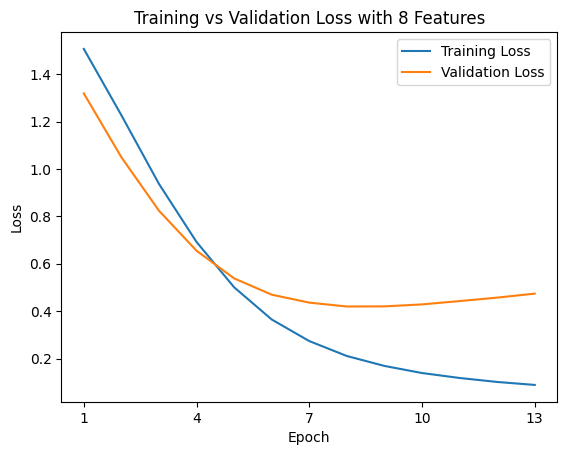

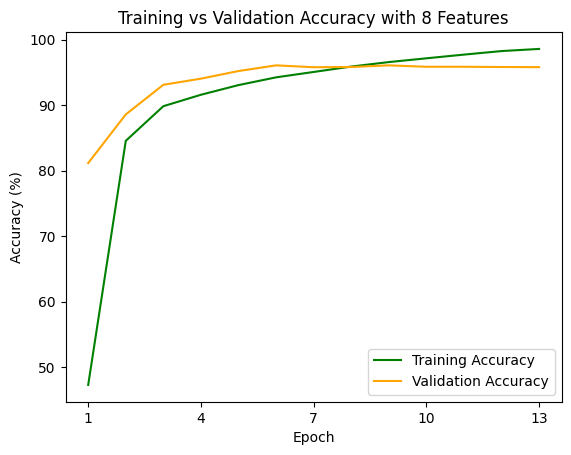

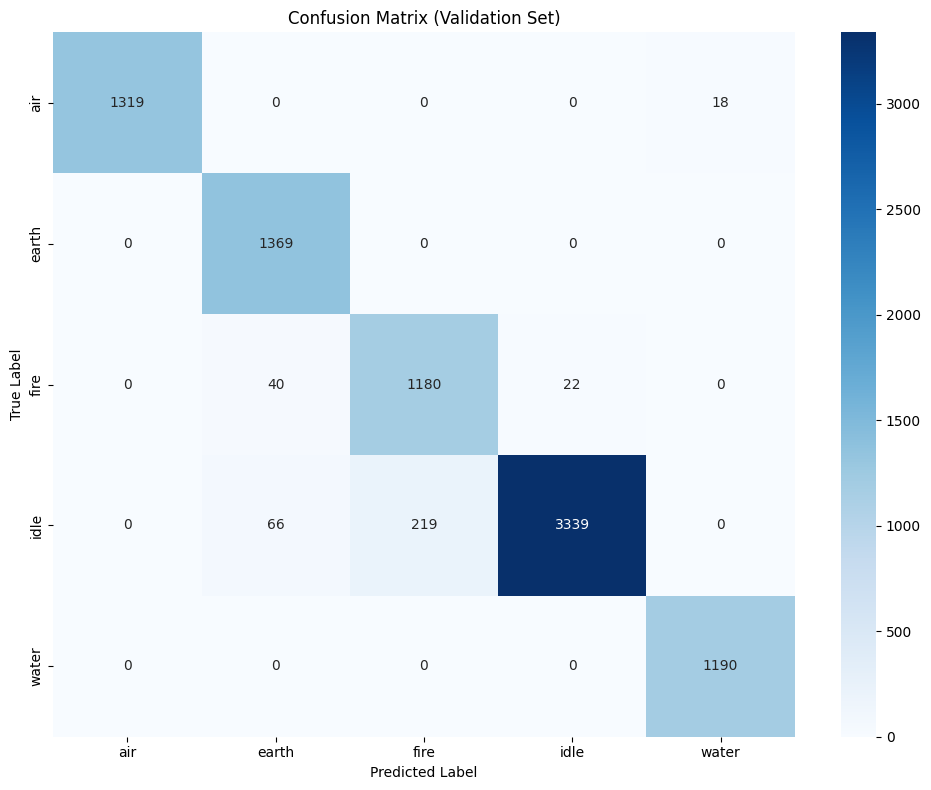

Classification Report (Validation Set):
              precision    recall  f1-score   support

         air       1.00      0.99      0.99      1337
       earth       0.93      1.00      0.96      1369
        fire       0.84      0.95      0.89      1242
        idle       0.99      0.92      0.96      3624
       water       0.99      1.00      0.99      1190

    accuracy                           0.96      8762
   macro avg       0.95      0.97      0.96      8762
weighted avg       0.96      0.96      0.96      8762



In [37]:
# Early-stopping training run (uses the same train/val loaders and PoseClassifier)
model = PoseClassifier()
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-5
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

max_epochs = 50
patience = 5
min_delta = 1e-4

best_val_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0
best_model_state = None

es_train_losses = []
es_val_losses = []
es_train_accuracies = []
es_val_accuracies = []

for epoch in range(1, max_epochs + 1):
    print(f"Epoch {epoch}\n-------------------------------")

    train_loss, train_acc = train_loop(train_loader, model, criterion, optimizer)
    val_loss, val_acc = test_loop(val_loader, model, criterion)

    es_train_losses.append(train_loss)
    es_val_losses.append(val_loss)
    es_train_accuracies.append(train_acc)
    es_val_accuracies.append(val_acc)

    print(f"Train Accuracy: {(100 * train_acc):>0.1f}%")

    if val_loss < (best_val_loss - min_delta):
        best_val_loss = val_loss
        best_epoch = epoch
        epochs_without_improvement = 0
        best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"Validation loss improved to {best_val_loss:.6f}")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement}/{patience} epoch(s)")

    if epochs_without_improvement >= patience:
        print(f"Early stopping triggered at epoch {epoch}")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)

print(f"Done! Loaded best model from epoch {best_epoch} (val loss: {best_val_loss:.6f})")

# Plot metrics from the early-stopping run
trained_epochs = len(es_train_losses)
epoch_range = range(1, trained_epochs + 1)
epoch_ticks = sorted(set(np.linspace(1, trained_epochs, num=min(5, trained_epochs), dtype=int).tolist()))

plt.plot(epoch_range, es_train_losses, label="Training Loss")
plt.plot(epoch_range, es_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss with 8 Features")
plt.xticks(epoch_ticks)
plt.legend()
plt.show()

plt.plot(epoch_range, [acc * 100 for acc in es_train_accuracies], label="Training Accuracy", color="green")
plt.plot(epoch_range, [acc * 100 for acc in es_val_accuracies], label="Validation Accuracy", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy with 8 Features")
plt.xticks(epoch_ticks)
plt.legend()
plt.show()

# Confusion matrix on validation set
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        logits = model(X_batch)
        preds = torch.argmax(logits, dim=1)
        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

class_names = encoder.classes_
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Validation Set)")
plt.tight_layout()
plt.show()

print("Classification Report (Validation Set):")
print(classification_report(y_true, y_pred, target_names=class_names))

Epoch 1
-------------------------------
Train Accuracy: 63.4%
Validation Accuracy: 83.6%
Epoch 2
-------------------------------
Train Accuracy: 93.4%
Validation Accuracy: 77.1%
Epoch 3
-------------------------------
Train Accuracy: 97.3%
Validation Accuracy: 77.6%
Epoch 4
-------------------------------
Train Accuracy: 98.7%
Validation Accuracy: 77.3%
Epoch 5
-------------------------------
Train Accuracy: 99.3%
Validation Accuracy: 76.4%
Epoch 6
-------------------------------
Train Accuracy: 99.5%
Validation Accuracy: 75.2%
Epoch 7
-------------------------------
Train Accuracy: 99.6%
Validation Accuracy: 74.1%
Epoch 8
-------------------------------
Train Accuracy: 99.7%
Validation Accuracy: 73.6%
Epoch 9
-------------------------------
Train Accuracy: 99.7%
Validation Accuracy: 73.5%
Epoch 10
-------------------------------
Train Accuracy: 99.8%
Validation Accuracy: 73.8%
Epoch 11
-------------------------------
Train Accuracy: 99.8%
Validation Accuracy: 74.1%
Epoch 12
----------

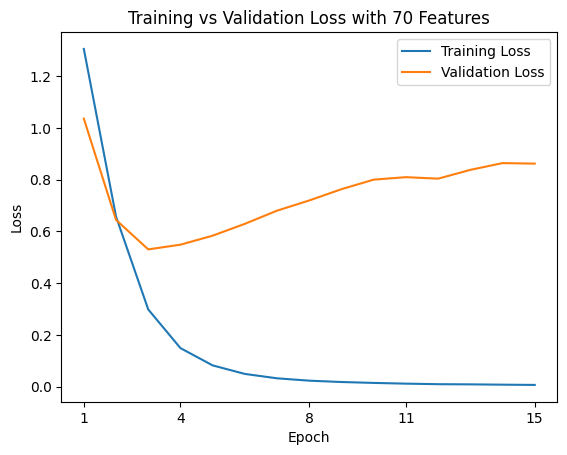

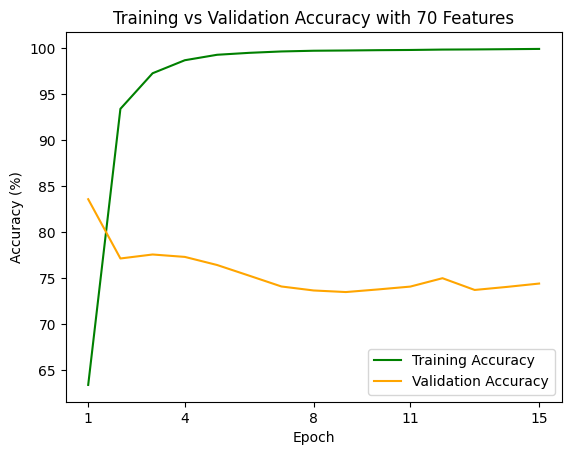

In [25]:
# Separate 70-feature training run: 66 normalized landmark coordinates + 4 angles

def preprocess_pose_data_70(X_raw):
    X = X_raw.reshape(-1, 33, 2)
    N = X.shape[0]

    # Keep the same normalization strategy as the existing experiment
    hip_center = (X[:, 24] + X[:, 23]) / 2
    X = X - hip_center[:, None, :]

    shoulder_center = (X[:, 12] + X[:, 11]) / 2
    torso_length = np.linalg.norm(shoulder_center, axis=1)
    torso_length = np.maximum(torso_length, 1e-6)
    X_scaled = X / torso_length[:, None, None]

    angles = np.zeros((N, 4))
    for i in range(N):
        angles[i, 0] = calculate_angle(X_scaled[i, 11], X_scaled[i, 13], X_scaled[i, 15])
        angles[i, 1] = calculate_angle(X_scaled[i, 12], X_scaled[i, 14], X_scaled[i, 16])
        angles[i, 2] = calculate_angle(X_scaled[i, 23], X_scaled[i, 11], X_scaled[i, 13])
        angles[i, 3] = calculate_angle(X_scaled[i, 24], X_scaled[i, 12], X_scaled[i, 14])

    landmark_features = X_scaled.reshape(N, -1)
    return np.hstack([landmark_features, angles])

X_train_70 = preprocess_pose_data_70(train_df.drop('label', axis=1).values)
X_val_70 = preprocess_pose_data_70(val_df.drop('label', axis=1).values)

global_scaler_70 = StandardScaler()
X_train_70_scaled = global_scaler_70.fit_transform(X_train_70)
X_val_70_scaled = global_scaler_70.transform(X_val_70)

y_train_70 = encoder.transform(train_df['label'].values)
y_val_70 = encoder.transform(val_df['label'].values)

X_train_70_tensor = torch.tensor(X_train_70_scaled).float()
y_train_70_tensor = torch.tensor(y_train_70).long()
X_val_70_tensor = torch.tensor(X_val_70_scaled).float()
y_val_70_tensor = torch.tensor(y_val_70).long()

train_dataset_70 = TensorDataset(X_train_70_tensor, y_train_70_tensor)
val_dataset_70 = TensorDataset(X_val_70_tensor, y_val_70_tensor)

train_loader_70 = DataLoader(train_dataset_70, batch_size=32, shuffle=True)
val_loader_70 = DataLoader(val_dataset_70, batch_size=32, shuffle=False)

class PoseClassifier70(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(70, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 5)
        )

    def forward(self, x):
        return self.model(x)

model_70 = PoseClassifier70()
criterion_70 = nn.CrossEntropyLoss()
optimizer_70 = torch.optim.Adam(model_70.parameters(), lr=1e-5)
epochs_70 = 15

train_losses_70 = []
val_losses_70 = []
train_accuracies_70 = []
val_accuracies_70 = []

def train_loop_70(dataloader, model, loss_fn, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    for X_batch, y_batch in dataloader:
        pred = model(X_batch)
        loss = loss_fn(pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (pred.argmax(1) == y_batch).type(torch.float).sum().item()

    return total_loss / num_batches, correct / size


def eval_loop_70(dataloader, model, loss_fn):
    model.eval()
    total_loss = 0
    correct = 0
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            pred = model(X_batch)
            loss = loss_fn(pred, y_batch)
            total_loss += loss.item()
            correct += (pred.argmax(1) == y_batch).type(torch.float).sum().item()

    return total_loss / num_batches, correct / size

for epoch in range(epochs_70):
    print(f"Epoch {epoch + 1}\n-------------------------------")

    train_loss_70, train_acc_70 = train_loop_70(train_loader_70, model_70, criterion_70, optimizer_70)
    val_loss_70, val_acc_70 = eval_loop_70(val_loader_70, model_70, criterion_70)

    train_losses_70.append(train_loss_70)
    val_losses_70.append(val_loss_70)
    train_accuracies_70.append(train_acc_70)
    val_accuracies_70.append(val_acc_70)

    print(f"Train Accuracy: {(100 * train_acc_70):>0.1f}%")
    print(f"Validation Accuracy: {(100 * val_acc_70):>0.1f}%")

print("Done!")

epoch_range_70 = range(1, epochs_70 + 1)
epoch_ticks_70 = sorted(set(np.linspace(1, epochs_70, num=min(5, epochs_70), dtype=int).tolist()))

plt.plot(epoch_range_70, train_losses_70, label="Training Loss")
plt.plot(epoch_range_70, val_losses_70, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss with 70 Features")
plt.xticks(epoch_ticks_70)
plt.legend()
plt.show()

plt.plot(epoch_range_70, [acc * 100 for acc in train_accuracies_70], label="Training Accuracy", color="green")
plt.plot(epoch_range_70, [acc * 100 for acc in val_accuracies_70], label="Validation Accuracy", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy with 70 Features")
plt.xticks(epoch_ticks_70)
plt.legend()
plt.show()

Shape: (57850, 8), finite values: True
Value range after stabilization: [-5.530, 2.331]


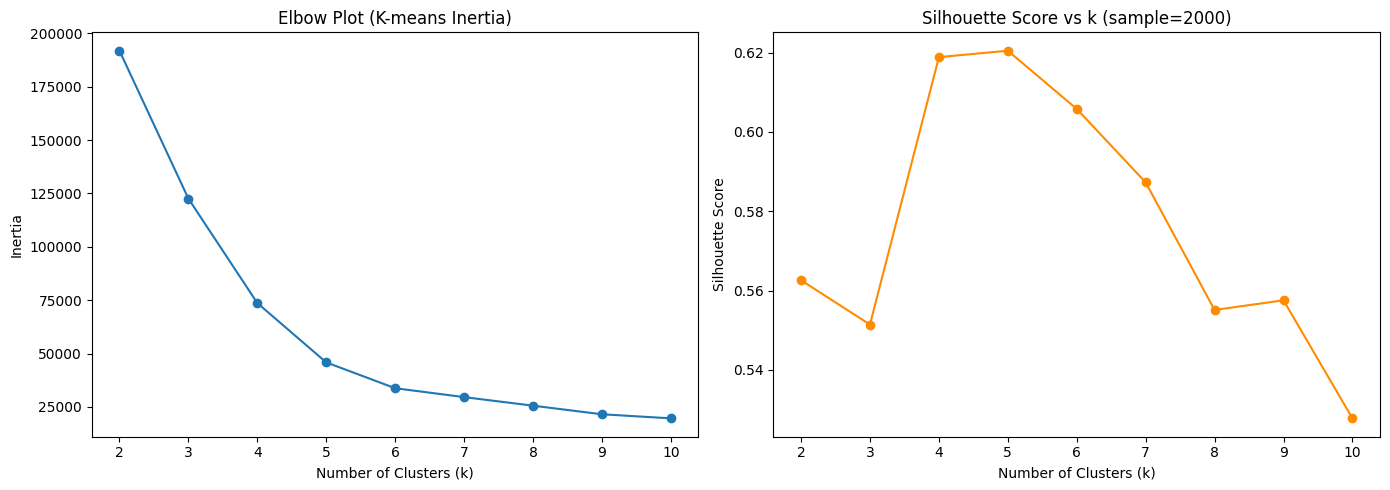

Best k by silhouette: 5


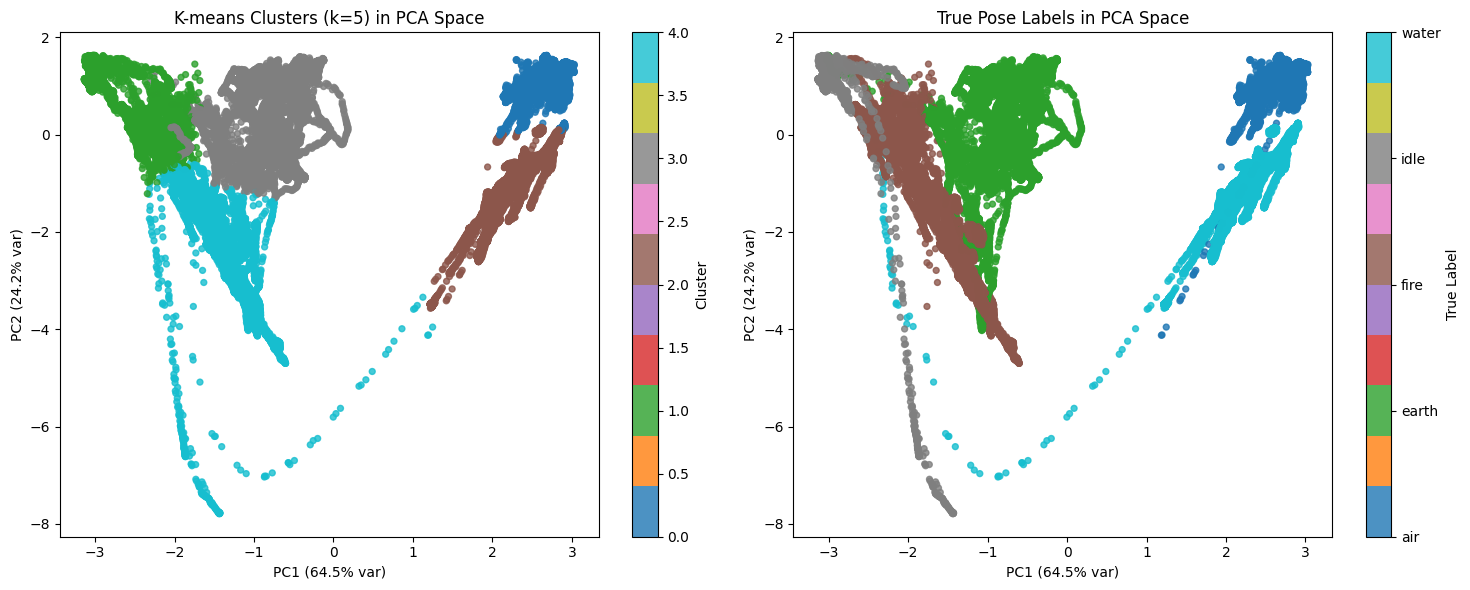

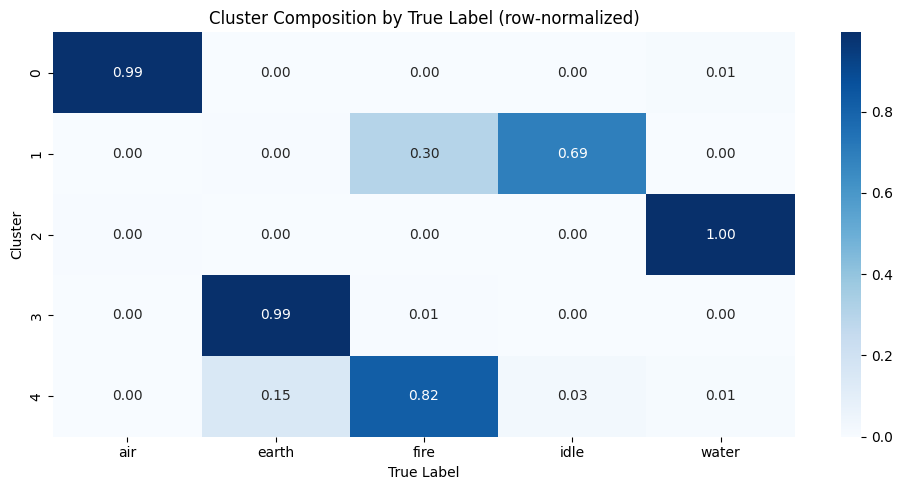

In [26]:
# K-means clustering analysis on pose features
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings

# Combine train and validation features for unsupervised clustering
X_all_raw = np.vstack([X_train_scaled, X_val_scaled]).astype(np.float64)
y_all = np.concatenate([y_train, y_val])
class_names = encoder.classes_

# Clean numeric issues to avoid overflow/invalid warnings in sklearn
X_all = np.nan_to_num(X_all_raw, nan=0.0, posinf=0.0, neginf=0.0)
X_all = np.clip(X_all, -8.0, 8.0)
feature_std = X_all.std(axis=0, keepdims=True)
feature_std = np.where(feature_std == 0, 1.0, feature_std)
X_all = X_all / feature_std

print(f'Shape: {X_all.shape}, finite values: {np.isfinite(X_all).all()}')
print(f'Value range after stabilization: [{X_all.min():.3f}, {X_all.max():.3f}]')
warnings.filterwarnings('ignore', message='.*encountered in matmul.*', category=RuntimeWarning)

# 1) Elbow (inertia) and silhouette analysis
k_values = range(2, 11)
inertias = []
silhouette_scores = []

# Use sampling for silhouette to keep runtime manageable on large datasets
sil_sample_size = min(2000, len(X_all))

for k in k_values:
    kmeans_k = KMeans(n_clusters=k, random_state=42, n_init=20)
    clusters_k = kmeans_k.fit_predict(X_all)
    inertias.append(kmeans_k.inertia_)
    silhouette_scores.append(
        silhouette_score(X_all, clusters_k, sample_size=sil_sample_size, random_state=42)
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_values, inertias, marker='o')
axes[0].set_title('Elbow Plot (K-means Inertia)')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(k_values))

axes[1].plot(k_values, silhouette_scores, marker='o', color='darkorange')
axes[1].set_title(f'Silhouette Score vs k (sample={sil_sample_size})')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(k_values))
plt.tight_layout()
plt.show()

# Choose k by best silhouette score
best_k = list(k_values)[int(np.argmax(silhouette_scores))]
print(f'Best k by silhouette: {best_k}')

# 2) Fit final K-means model
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_all)

# 3) PCA projection for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: colored by cluster
sc1 = axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    cmap='tab10',
    s=18,
    alpha=0.8
)
axes[0].set_title(f'K-means Clusters (k={best_k}) in PCA Space')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.colorbar(sc1, ax=axes[0], label='Cluster')

# Right: colored by true label
sc2 = axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_all,
    cmap='tab10',
    s=18,
    alpha=0.8
)
axes[1].set_title('True Pose Labels in PCA Space')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
cbar = plt.colorbar(sc2, ax=axes[1], ticks=np.arange(len(class_names)))
cbar.set_label('True Label')
cbar.ax.set_yticklabels(class_names)

plt.tight_layout()
plt.show()

# 4) Cluster vs true-label composition heatmap
ct = pd.crosstab(
    pd.Series(cluster_labels, name='Cluster'),
    pd.Series([class_names[i] for i in y_all], name='True Label'),
    normalize='index'
)

plt.figure(figsize=(10, 5))
sns.heatmap(ct, annot=True, fmt='.2f', cmap='Blues')
plt.title('Cluster Composition by True Label (row-normalized)')
plt.ylabel('Cluster')
plt.xlabel('True Label')
plt.tight_layout()
plt.show()

In [27]:
# Exploratory data analysis
# Class distribution 
"""unique, counts = np.unique(y, return_counts=True)
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()"""


'unique, counts = np.unique(y, return_counts=True)\nplt.bar(unique, counts)\nplt.xlabel("Class")\nplt.ylabel("Count")\nplt.title("Class Distribution")\nplt.show()'

In [28]:
# Explore if data is similar ranges
"""feature_names = [col for col in data.columns if col != 'label']
df_scaled = pd.DataFrame(X, columns=feature_names)

df_scaled.hist(bins=30, figsize=(20, 30))
plt.suptitle("Feature Distributions (after normalisation)", y=1.01)
plt.tight_layout()
plt.show()"""

'feature_names = [col for col in data.columns if col != \'label\']\ndf_scaled = pd.DataFrame(X, columns=feature_names)\n\ndf_scaled.hist(bins=30, figsize=(20, 30))\nplt.suptitle("Feature Distributions (after normalisation)", y=1.01)\nplt.tight_layout()\nplt.show()'

In [29]:

# 3. CORRELATION MATRIX — which landmarks are redundant

"""corr = df_scaled.corr()
plt.figure(figsize=(16, 14))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix (66 landmarks)")
plt.tight_layout()
plt.show()

# Flag highly correlated pairs
high_corr = []
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if abs(corr.iloc[i, j]) > 0.95:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

print(f"\nHighly correlated pairs (|r| > 0.95): {len(high_corr)}")
for f1, f2, r in high_corr[:10]:
    print(f"  {f1} <-> {f2}: {r:.3f}")"""

'corr = df_scaled.corr()\nplt.figure(figsize=(16, 14))\nsns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)\nplt.title("Feature Correlation Matrix (66 landmarks)")\nplt.tight_layout()\nplt.show()\n\n# Flag highly correlated pairs\nhigh_corr = []\nfor i in range(len(corr)):\n    for j in range(i+1, len(corr)):\n        if abs(corr.iloc[i, j]) > 0.95:\n            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))\n\nprint(f"\nHighly correlated pairs (|r| > 0.95): {len(high_corr)}")\nfor f1, f2, r in high_corr[:10]:\n    print(f"  {f1} <-> {f2}: {r:.3f}")'

In [30]:
# 4. PCA

"""from sklearn.decomposition import PCA
class_names = encoder.classes_
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
for c in np.unique(y):
    mask = y == c
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=class_names[c], alpha=0.5, s=15)

plt.legend()
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("PCA — 2D Projection of Pose Data")
plt.show()"""

'from sklearn.decomposition import PCA\nclass_names = encoder.classes_\npca = PCA(n_components=2)\nX_2d = pca.fit_transform(X)\n\nplt.figure(figsize=(8, 6))\nfor c in np.unique(y):\n    mask = y == c\n    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=class_names[c], alpha=0.5, s=15)\n\nplt.legend()\nplt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")\nplt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")\nplt.title("PCA — 2D Projection of Pose Data")\nplt.show()'

In [31]:
# 5. SPLIT VERIFICATION - train and test distributions


"""fig, axes = plt.subplots(1, 2, figsize=(12, 4))

unique_tr, counts_tr = np.unique(y_train, return_counts=True)
unique_te, counts_te = np.unique(y_test, return_counts=True)

axes[0].bar(class_names[unique_tr], counts_tr / len(y_train))
axes[0].set_title("Train — Class Proportions")
axes[0].set_ylabel("Proportion")
axes[0].set_ylim(0, 1)

axes[1].bar(class_names[unique_te], counts_te / len(y_test))
axes[1].set_title("Test — Class Proportions")
axes[1].set_ylabel("Proportion")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Feature distribution comparison (first 6 features)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i in range(6):
    axes[i].hist(X_train[:, i], bins=30, alpha=0.5, label="Train", density=True)
    axes[i].hist(X_test[:, i], bins=30, alpha=0.5, label="Test", density=True)
    axes[i].set_title(feature_names[i])
    axes[i].legend()
plt.suptitle("Train vs Test Feature Distributions")
plt.tight_layout()
plt.show()

# Statistical test
from scipy.stats import ks_2samp
mismatches = 0
for i in range(X_train.shape[1]):
    stat, p_value = ks_2samp(X_train[:, i], X_test[:, i])
    if p_value < 0.05:
        mismatches += 1
print(f"Features with significantly different train/test distributions: {mismatches}/{X_train.shape[1]}")"""

'fig, axes = plt.subplots(1, 2, figsize=(12, 4))\n\nunique_tr, counts_tr = np.unique(y_train, return_counts=True)\nunique_te, counts_te = np.unique(y_test, return_counts=True)\n\naxes[0].bar(class_names[unique_tr], counts_tr / len(y_train))\naxes[0].set_title("Train — Class Proportions")\naxes[0].set_ylabel("Proportion")\naxes[0].set_ylim(0, 1)\n\naxes[1].bar(class_names[unique_te], counts_te / len(y_test))\naxes[1].set_title("Test — Class Proportions")\naxes[1].set_ylabel("Proportion")\naxes[1].set_ylim(0, 1)\n\nplt.tight_layout()\nplt.show()\n\n# Feature distribution comparison (first 6 features)\nfig, axes = plt.subplots(2, 3, figsize=(15, 8))\naxes = axes.flatten()\nfor i in range(6):\n    axes[i].hist(X_train[:, i], bins=30, alpha=0.5, label="Train", density=True)\n    axes[i].hist(X_test[:, i], bins=30, alpha=0.5, label="Test", density=True)\n    axes[i].set_title(feature_names[i])\n    axes[i].legend()\nplt.suptitle("Train vs Test Feature Distributions")\nplt.tight_layout()\nplt

In [32]:
# TEMPORAL LEAKAGE CHECK — similarity of consecutive samples


# Computes distance between consecutive frames in the org data
"""consecutive_dists = np.linalg.norm(X[1:] - X[:-1], axis=1)
random_pairs = np.random.choice(len(X), size=(len(X)-1, 2), replace=True)
random_dists = np.linalg.norm(X[random_pairs[:, 0]] - X[random_pairs[:, 1]], axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(consecutive_dists, bins=50, alpha=0.5, label="Consecutive frames", density=True)
ax.hist(random_dists, bins=50, alpha=0.5, label="Random pairs", density=True)
ax.set_xlabel("Euclidean distance between samples")
ax.set_title("Temporal Correlation Check")
ax.legend()
plt.show()

print(f"Median distance between consecutive frames: {np.median(consecutive_dists):.3f}")
print(f"Median distance between random pairs: {np.median(random_dists):.3f}")
print(f"Ratio: {np.median(random_dists) / np.median(consecutive_dists):.1f}x")"""

'consecutive_dists = np.linalg.norm(X[1:] - X[:-1], axis=1)\nrandom_pairs = np.random.choice(len(X), size=(len(X)-1, 2), replace=True)\nrandom_dists = np.linalg.norm(X[random_pairs[:, 0]] - X[random_pairs[:, 1]], axis=1)\n\nfig, ax = plt.subplots(figsize=(10, 4))\nax.hist(consecutive_dists, bins=50, alpha=0.5, label="Consecutive frames", density=True)\nax.hist(random_dists, bins=50, alpha=0.5, label="Random pairs", density=True)\nax.set_xlabel("Euclidean distance between samples")\nax.set_title("Temporal Correlation Check")\nax.legend()\nplt.show()\n\nprint(f"Median distance between consecutive frames: {np.median(consecutive_dists):.3f}")\nprint(f"Median distance between random pairs: {np.median(random_dists):.3f}")\nprint(f"Ratio: {np.median(random_dists) / np.median(consecutive_dists):.1f}x")'

In [33]:
%pip install -q onnx


[notice] A new release of pip available: 22.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [34]:
class PoseClassifierWithSoftmax(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        logits = self.base_model(x)
        return self.softmax(logits)

model.eval()

export_model = PoseClassifierWithSoftmax(model)
export_model.eval()

torch.onnx.export(
    export_model,
    torch.randn(1, 8),
    "pose_classifier.onnx",
    input_names=["input"],
    output_names=["output"],
    external_data=False,
    dynamic_shapes={"x": {0: "batch"}}
)

# scaler and labels export remain the same
scaler_params = {
    "mean": scaler.mean_.tolist(),
    "std": scaler.scale_.tolist()
}
with open("pose_scaler.json", "w") as f:
    json.dump(scaler_params, f)

label_mapping = {}
for i, name in enumerate(encoder.classes_):
    label_mapping[str(i)] = name

with open("pose_labels.json", "w") as f:
    json.dump(label_mapping, f)

print("Exported with softmax baked in - output is now probabilities [0, 1]")
print(f"Labels: {label_mapping}")


W0423 12:36:11.820890 73860 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0423 12:36:11.821482 73860 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_align
W0423 12:36:11.821940 73860 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_pool


[torch.onnx] Obtain model graph for `PoseClassifierWithSoftmax([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `PoseClassifierWithSoftmax([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Exported with softmax baked in - output is now probabilities [0, 1]
Labels: {'0': 'air', '1': 'earth', '2': 'fire', '3': 'idle', '4': 'water'}


/Users/kaungzawhan/.pyenv/versions/3.10.6/lib/python3.10/copyreg.py:101: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
